# Bibliotekos

In [ ]:
library(here)
library(tidyverse)
library(patchwork)
library(scales)
library(cowplot)

Warning message:
"package 'here' was built under R version 4.5.3"
here() starts at C:/Users/rugil/Desktop/uni/TreciasKursas/pavasaris/DuomenuMoksloProjektas/Duomenu_mokslo_projektas

Warning message:
"package 'tidyverse' was built under R version 4.5.3"
Warning message:
"package 'ggplot2' was built under R version 4.5.3"
Warning message:
"package 'tibble' was built under R version 4.5.3"
Warning message:
"package 'tidyr' was built under R version 4.5.3"
Warning message:
"package 'readr' was built under R version 4.5.3"
Warning message:
"package 'purrr' was built under R version 4.5.3"
Warning message:
"package 'dplyr' was built under R version 4.5.3"
Warning message:
"package 'stringr' was built under R version 4.5.3"
Warning message:
"package 'forcats' was built under R version 4.5.3"
Warning message:
"package 'lubridate' was built under R version 4.5.3"
── Attaching core tidyverse packages ──────────────────────── tidyverse 2.0.0 ──
✔ dplyr     1.2.1     ✔ readr     2.2.0
✔ forcats  

In [4]:
data <- read.csv(here("code", "python",
                      "datasets_prep", "dm_project_dataset.csv"))

data <- data |> rename('time' = observationTime)
data <- data |> dplyr::mutate(time = ymd(time))
names(data)

[1] "time"                                   
 [2] "absorbing_aerosol_index"                
 [3] "NO2_column_number_density"              
 [4] "stratospheric_NO2_column_number_density"
 [5] "NO2_slant_column_number_density"        
 [6] "tropopause_pressure"                    
 [7] "H2O_column_number_density"              
 [8] "BrO"                                    
 [9] "BrO_Error"                              
[10] "NO2"                                    
[11] "NO2_Error"                              
[12] "O3"                                     
[13] "O3_Error"                               
[14] "pm10"                                   
[15] "pm2p5"                                  
[16] "sia"                                    
[17] "nmvoc"                                  
[18] "dust"                                   
[19] "nh3"                                    
[20] "pans"                                   
[21] "tp"                                     
[22] "t2m"                                    
[23] "airTemperature"                         
[24] "seaLevelPressure"                       
[25] "relativeHumidity"                       
[26] "missforest_precipitation"               
[27] "xgb_cloudCover"                         
[28] "feelsLikeTemperature_fixed"             
[29] "windSpeed_fixed"                        
[30] "windGust_fixed"                         
[31] "windDirection_fixed"

In [5]:
char_function_out <- function(df, columns = everything()) {
  df %>%
    select({{ columns }}) %>%
    select(where(is.numeric)) %>%
    summarise(across(everything(), 
                     list(min = ~min(.x, na.rm = TRUE), 
                          max = ~max(.x, na.rm = TRUE), 
                          mean = ~mean(.x, na.rm = TRUE),
                          sd = ~sd(.x, na.rm = TRUE),
                          q25 = ~quantile(.x, 0.25, na.rm = TRUE),
                          median = ~median(.x, na.rm = TRUE),
                          q75 = ~quantile(.x, 0.75, na.rm = TRUE)),
                     .names = "{.col}.{.fn}")) %>% 
    pivot_longer(everything(), 
                 names_to = c("variable", ".value"), 
                 names_sep = "\\.")
}

In [6]:
cols_to_analyze <- c("missforest_precipitation", "tp")

general_stats <- data %>% 
  char_function_out()

general_stats

variable,min,max,mean,sd,q25,median,q75
<chr>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
absorbing_aerosol_index,-2.990588e+00,3.069160e+00,-7.188289e-01,6.120347e-01,-1.138378e+00,-6.555738e-01,-2.884844e-01
NO2_column_number_density,2.730806e-06,4.994480e-04,7.868506e-05,2.896116e-05,6.528396e-05,7.640007e-05,8.654637e-05
stratospheric_NO2_column_number_density,7.723584e-06,8.146180e-05,4.173578e-05,1.714072e-05,2.524213e-05,4.183849e-05,5.749933e-05
NO2_slant_column_number_density,6.039153e-05,3.356557e-04,1.728230e-04,3.017163e-05,1.533367e-04,1.739311e-04,1.924995e-04
tropopause_pressure,9.582507e+03,2.759435e+04,1.825534e+04,2.879180e+03,1.667883e+04,1.794028e+04,1.926195e+04
H2O_column_number_density,5.750162e+01,5.807129e+03,9.903385e+02,6.583300e+02,4.747029e+02,8.295978e+02,1.351585e+03
BrO,1.162035e+12,8.077890e+13,4.068553e+13,1.088695e+13,3.399393e+13,4.065216e+13,4.762002e+13
BrO_Error,9.870329e+12,5.021661e+13,1.729022e+13,3.809121e+12,1.435706e+13,1.681813e+13,1.975258e+13
NO2,1.867652e+14,6.610976e+15,2.592926e+15,1.006219e+15,1.722114e+15,2.603094e+15,3.463748e+15


In [7]:
char_function_grouped <- function(df, columns, group_col) {
  df %>%
    group_by(across(all_of(group_col))) %>%
    select(all_of(group_col), all_of(columns)) %>%
    summarise(across(all_of(columns), 
                     list(min = ~min(.x, na.rm = TRUE), 
                          max = ~max(.x, na.rm = TRUE), 
                          mean = ~mean(.x, na.rm = TRUE),
                          sd = ~sd(.x, na.rm = TRUE),
                          q25 = ~quantile(.x, 0.25, na.rm = TRUE),
                          median = ~median(.x, na.rm = TRUE),
                          q75 = ~quantile(.x, 0.75, na.rm = TRUE)),
                     .names = "{.col}.{.fn}"),
              .groups = "drop") %>%
    pivot_longer(cols = -all_of(group_col), 
                 names_to = c("variable", ".value"), 
                 names_sep = "\\.")
}

In [8]:
cols_to_analyze <- c("missforest_precipitation", "tp")
my_colors <- c("Tikra" = "#f8766d", "Prognozė" = "#7ab6eeed")

data_with_year <- data %>%
  mutate(year = year(time))

stats_by_year <- data_with_year %>% 
  char_function_grouped(cols_to_analyze, "year")

stats_by_year <- stats_by_year %>%
  mutate(variable = recode(variable, 
                           "missforest_precipitation" = "Tikra", 
                           "tp" = "Prognozė"))

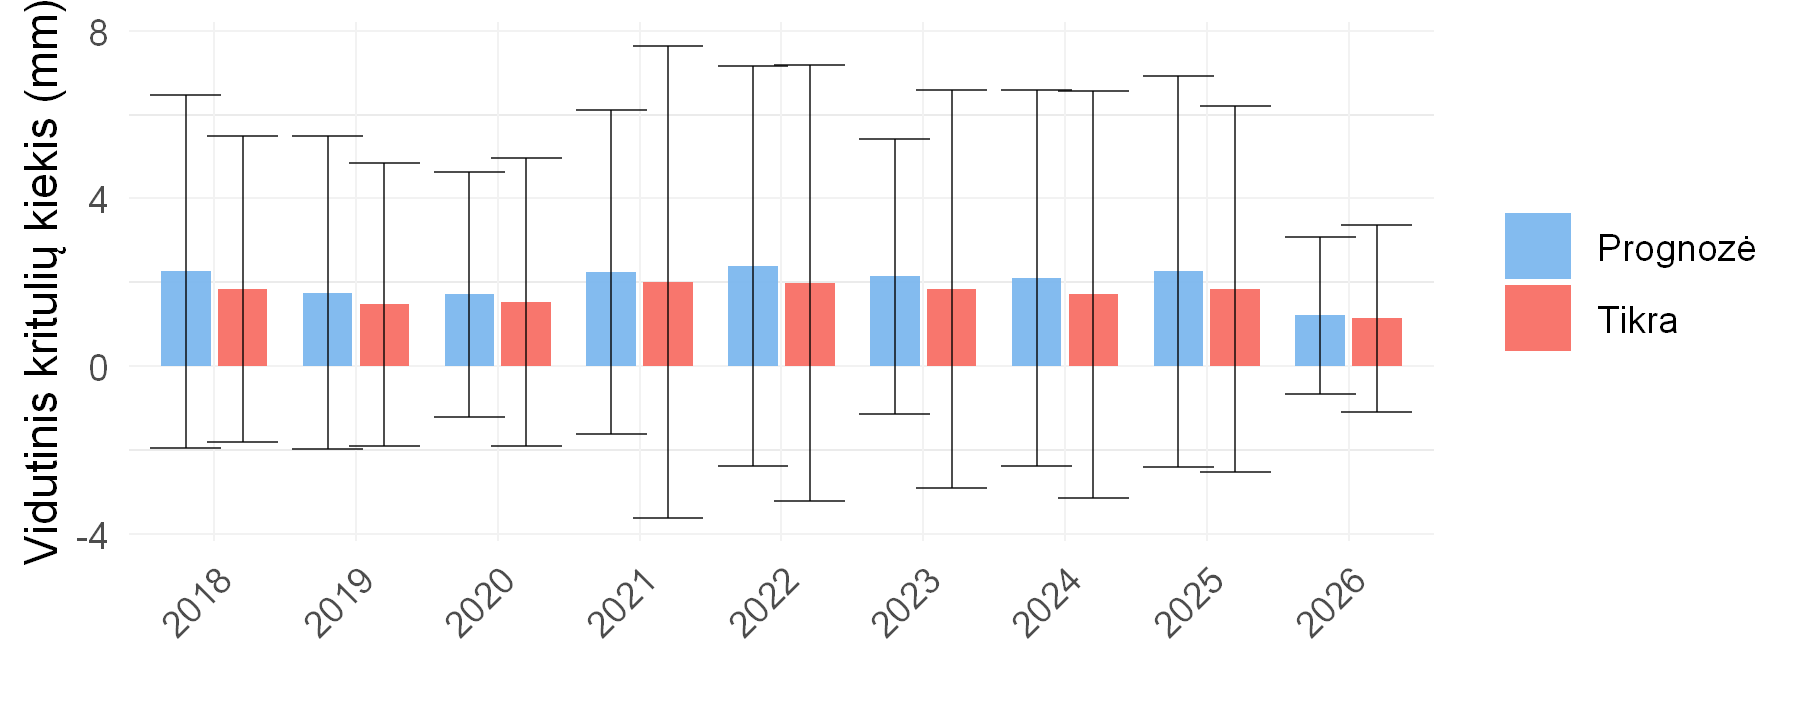

In [106]:
options(repr.plot.width = 6, repr.plot.height = 2.4)
p1 <- ggplot(stats_by_year, aes(x = factor(year), y = mean, fill = variable)) +
  geom_col(position = position_dodge(width = 0.8), width = 0.7) +
  geom_errorbar(aes(ymin = mean - sd, ymax = mean + sd), 
                position = position_dodge(width = 0.8), linewidth = 0.25,
                width = 1, color = "black", alpha = 0.7) +
  scale_fill_manual(values = my_colors) +
  theme_minimal() +
  labs(x = "", y = "Vidutinis kritulių kiekis (mm)", fill = NULL) +
  theme(axis.text.x = element_text(angle = 45, hjust = 1),
        panel.grid.major = element_line(color = "grey95", linewidth = 0.25))

p1

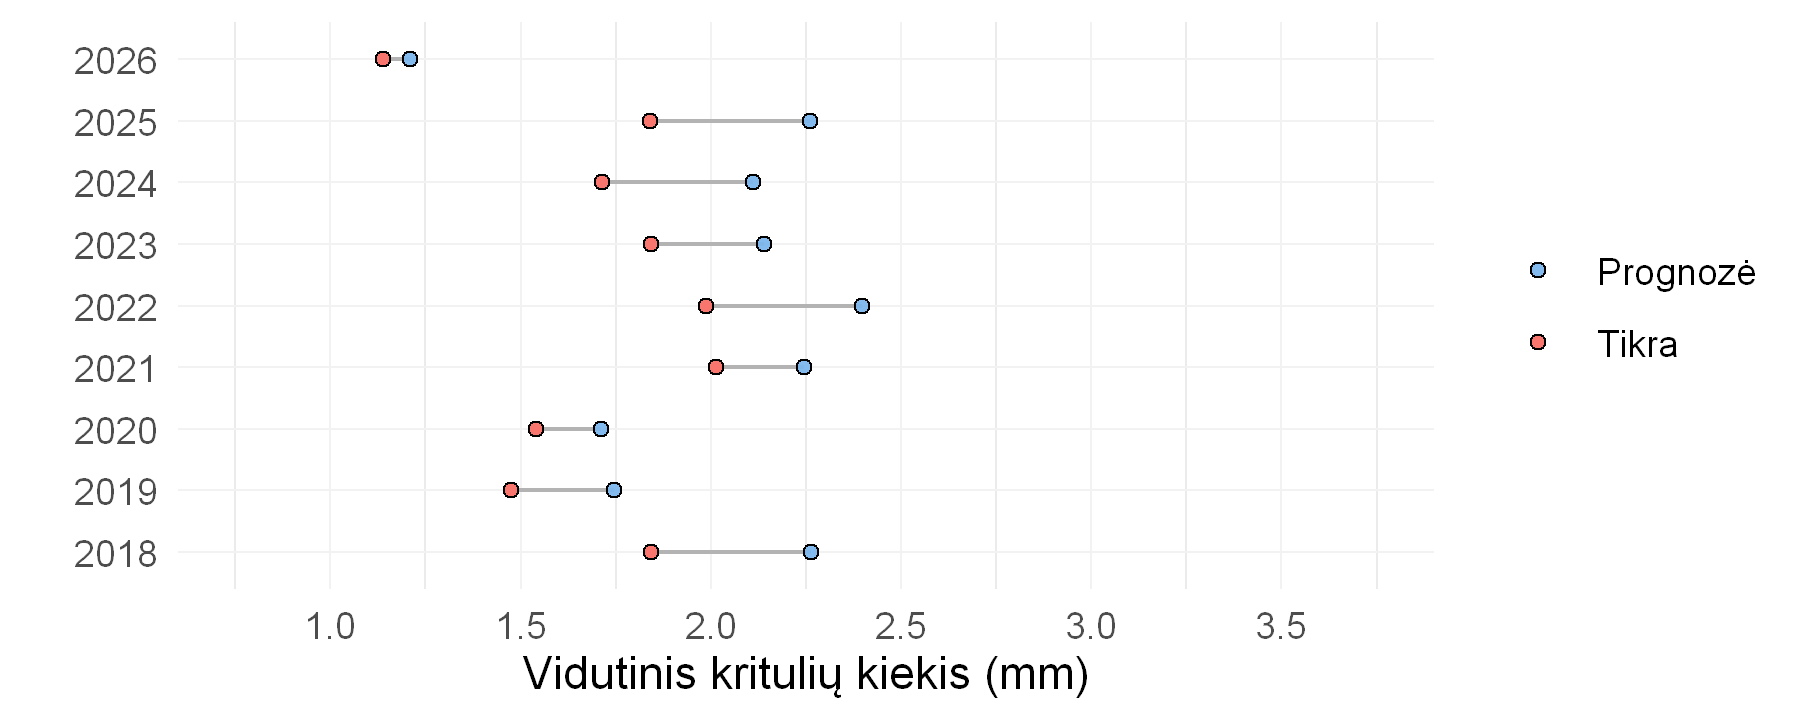

In [107]:
stats_wide <- stats_by_year %>%
  select(year, variable, mean) %>% 
  pivot_wider(names_from = variable, values_from = mean)

options(repr.plot.width = 6, repr.plot.height = 2.4)
p2 <- ggplot(stats_wide) +
  geom_segment(aes(
    x = factor(year), xend = factor(year), 
    y = Prognozė, yend = Tikra
  ), color = "grey70", linewidth = 0.5) +
  geom_point(aes(x = factor(year), y = Prognozė, fill = "Prognozė"), 
             size = 1.5, shape = 21) + 
  geom_point(aes(x = factor(year), y = Tikra, fill = "Tikra"), 
             size = 1.5, shape = 21) +
  scale_fill_manual(values = my_colors) +
  scale_y_continuous(breaks = seq(0, 4, by = 0.5), limits = c(0.75, 3.75)) +
  coord_flip() +
  theme_minimal() +
  labs(x = "", y = "Vidutinis kritulių kiekis (mm)", fill = NULL) +
  theme(panel.grid.major = element_line(color = "grey95", linewidth = 0.25))

p2

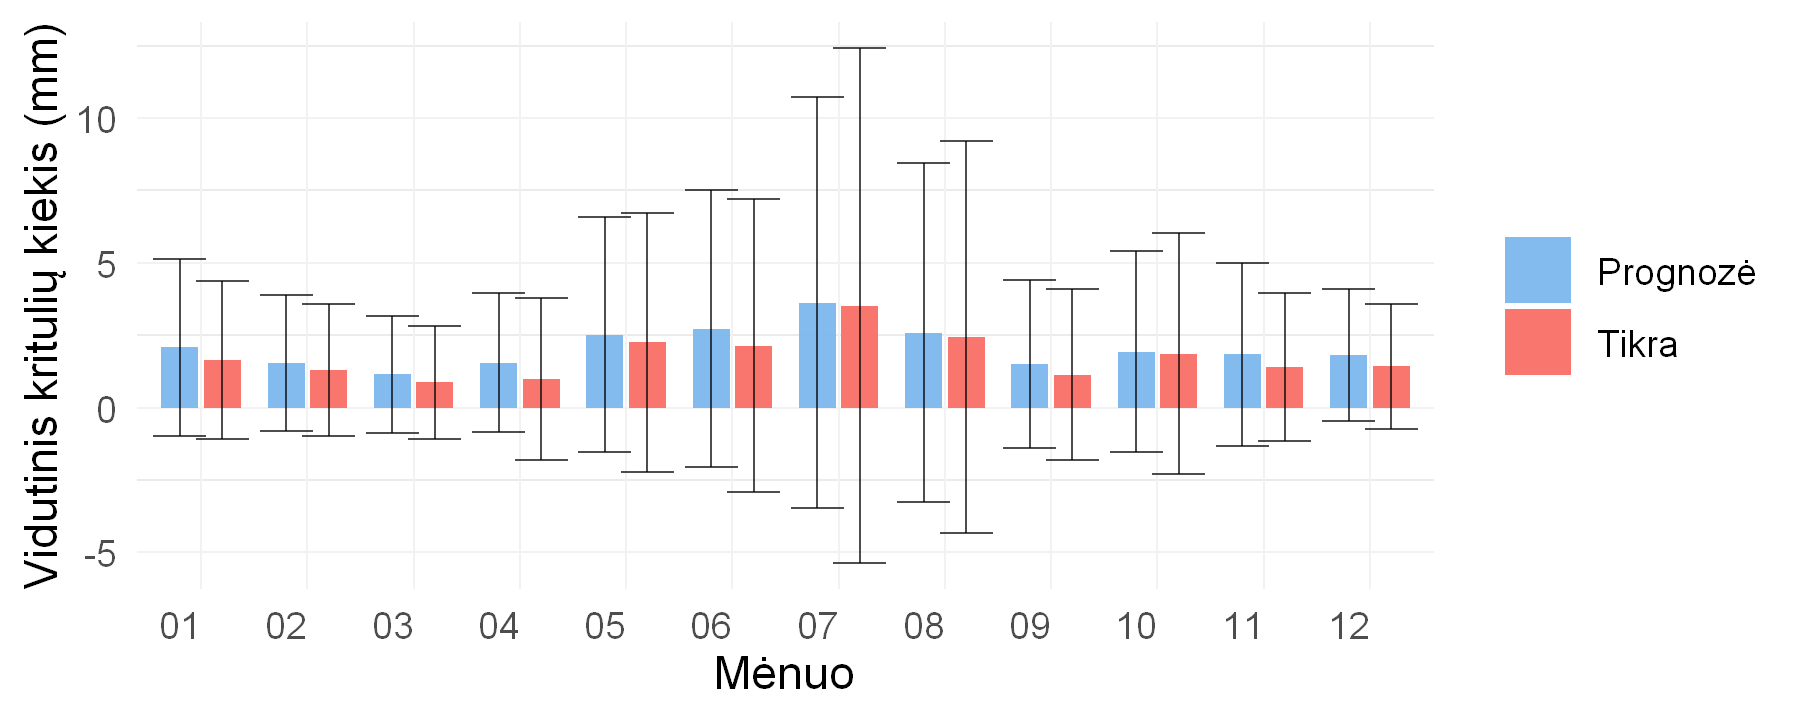

In [108]:
data_with_month <- data %>%
  mutate(month = month(time, label = TRUE, abbr = TRUE))

data_with_month <- data_with_month %>%
  mutate(month = sprintf("%02d", month(time)))

stats_by_month <- data_with_month %>% 
  char_function_grouped(cols_to_analyze, "month")

stats_by_month <- stats_by_month %>%
  mutate(variable = recode(variable, 
                           "missforest_precipitation" = "Tikra", 
                           "tp" = "Prognozė"))

p3 <- ggplot(stats_by_month, aes(x = factor(month), y = mean, fill = variable)) +
  geom_col(position = position_dodge(width = 0.8), width = 0.7) +
  geom_errorbar(aes(ymin = mean - sd, ymax = mean + sd), 
                position = position_dodge(width = 0.8), linewidth = 0.25,
                width = 1, color = "black", alpha = 0.7) +
  scale_fill_manual(values = my_colors) +
  theme_minimal() +
  labs(x = "Mėnuo", y = "Vidutinis kritulių kiekis (mm)", fill = NULL) +
  theme(axis.text.x = element_text(hjust = 1),
        panel.grid.major = element_line(color = "grey95", linewidth = 0.25))

p3


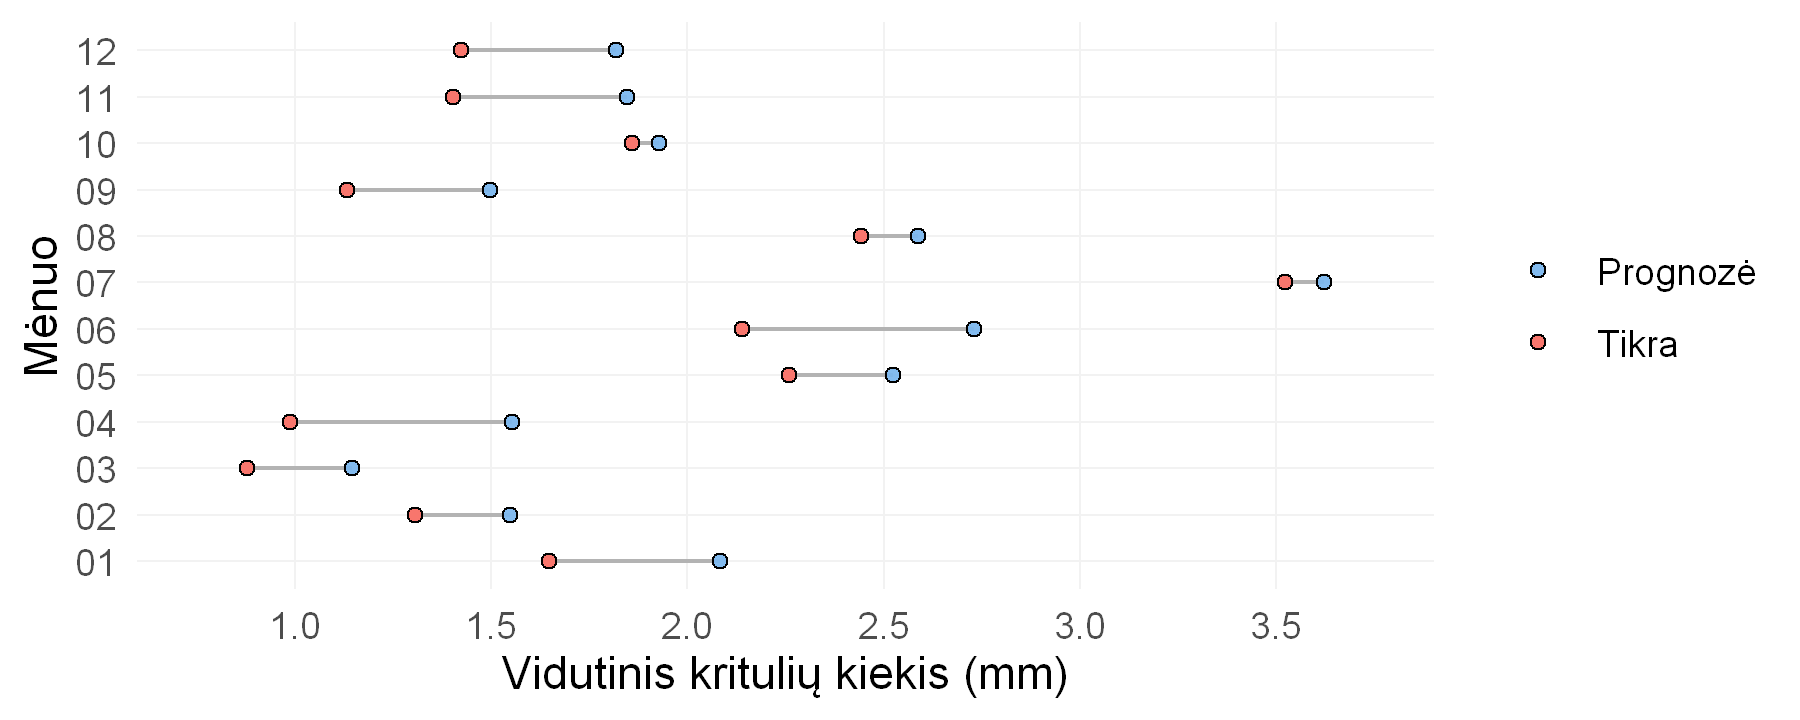

In [109]:
options(repr.plot.width = 6, repr.plot.height = 4)

stats_wide_month <- stats_by_month %>%
  select(month, variable, mean) %>% 
  pivot_wider(names_from = variable, values_from = mean)
  
options(repr.plot.width = 6, repr.plot.height = 2.4)
p4 <- ggplot(stats_wide_month) +
  geom_segment(aes(
    x = factor(month), xend = factor(month), 
    y = Prognozė, yend = Tikra
  ), color = "grey70", linewidth = 0.5) +
  geom_point(aes(x = factor(month), y = Prognozė, fill = "Prognozė"), 
             size = 1.5, shape = 21) + 
  geom_point(aes(x = factor(month), y = Tikra, fill = "Tikra"), 
             size = 1.5, shape = 21) +
  scale_fill_manual(values = my_colors) +
  scale_y_continuous(breaks = seq(0, 4, by = 0.5), limits = c(0.75, 3.75), minor_breaks = NULL, guide = guide_axis(check.overlap = FALSE)) +
  coord_flip() +
  theme_minimal() +
  labs(x = "Mėnuo", y = "Vidutinis kritulių kiekis (mm)", fill = NULL) +
  theme(panel.grid.major = element_line(color = "grey95", linewidth = 0.25))

p4

Scale for y is already present.
Adding another scale for y, which will replace the existing scale.
Scale for y is already present.
Adding another scale for y, which will replace the existing scale.


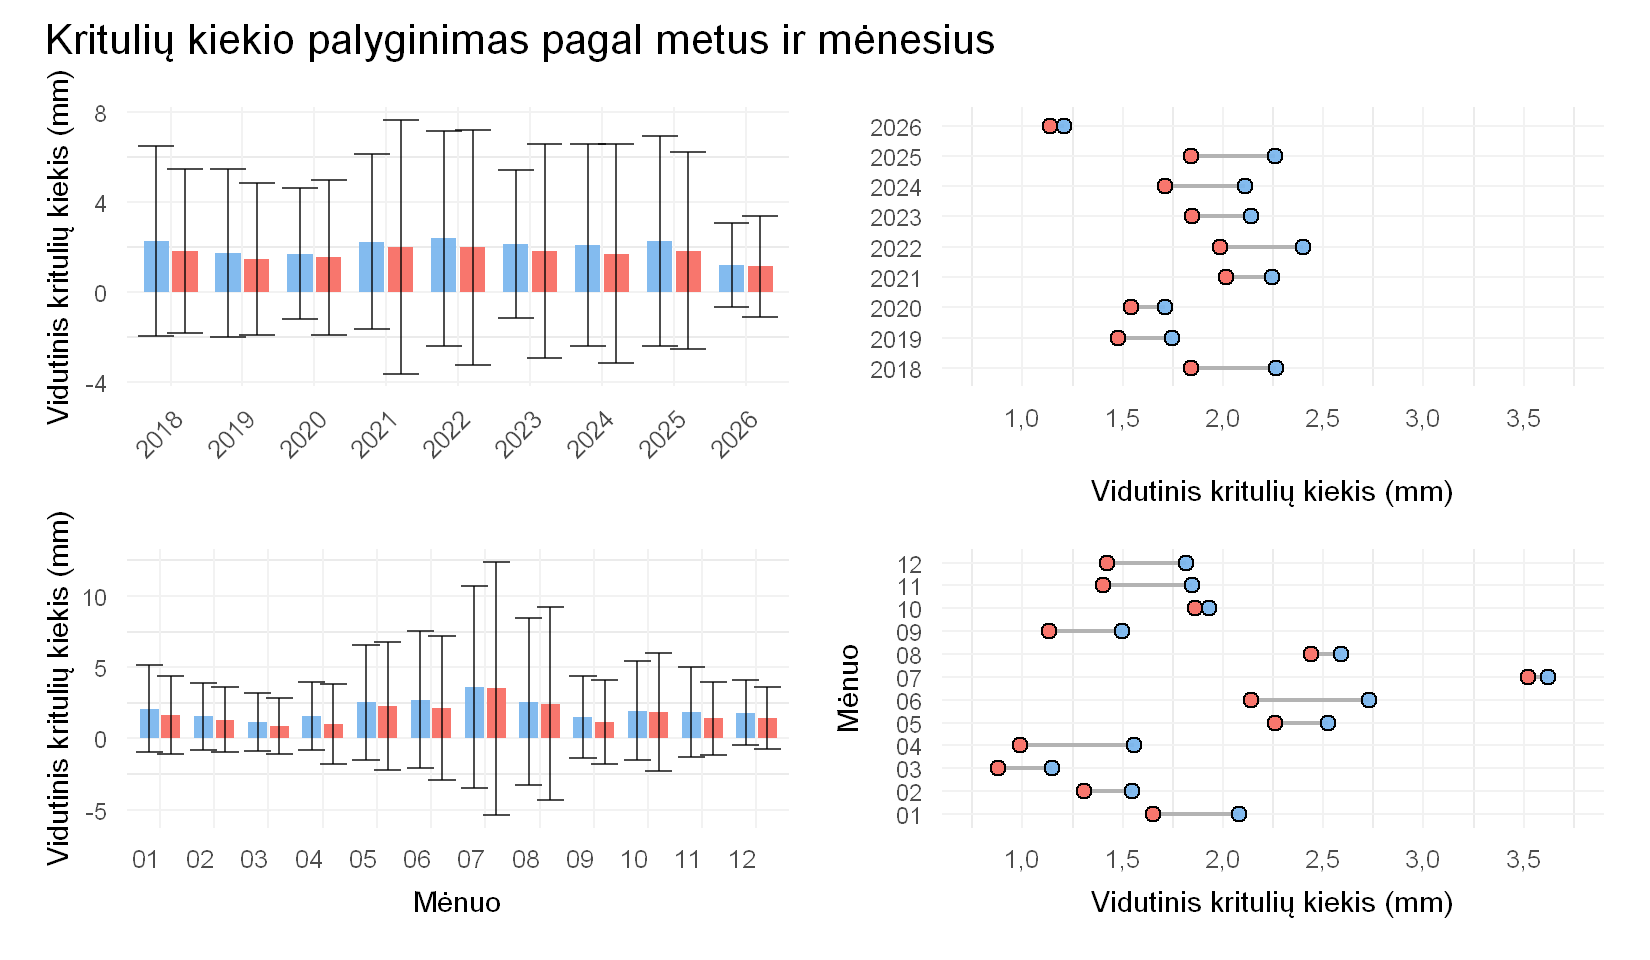

In [110]:
options(repr.plot.width = 5.5, repr.plot.height = 3.2, repr.plot.res = 300)
legend_plot <- get_legend(p1)

combined <- wrap_plots(
  p1 + theme(legend.position = "none"),
  p2 + guides(fill = "none") + 
    scale_y_continuous(
      labels = label_number(decimal.mark = ",", big.mark = "."),
      breaks = seq(0, 4, by = 0.5), 
      limits = c(0.75, 3.75)
    ),
  p3 + theme(legend.position = "none"),
  p4 + guides(fill = "none")+ 
    scale_y_continuous(
      labels = label_number(decimal.mark = ",", big.mark = "."),
      breaks = seq(0, 4, by = 0.5), 
      limits = c(0.75, 3.75)
    ),
  ncol = 2
) & theme(
    axis.title.y = element_text(size = 7),
    axis.title.x = element_text(size = 7),
    axis.text.x  = element_text(size = 6),
    axis.text.y  = element_text(size = 5.45)
  )

combined + plot_annotation(
  title = "Kritulių kiekio palyginimas pagal metus ir mėnesius",
  theme = theme(plot.title = element_text(size = 10))
)

ggsave(filename = "precipitation_year_month.png", width = 5.5,
  height = 3.2, units = "in",
  dpi = 300)

In [102]:
data_clean <- data %>%
    mutate(tp_lag = lag(tp, 1)) %>%
    mutate(tp_error = abs(tp_lag - missforest_precipitation)) %>%
    dplyr::select(-c('BrO_Error', 'NO2_Error', 'O3_Error')) %>%
    na.omit()

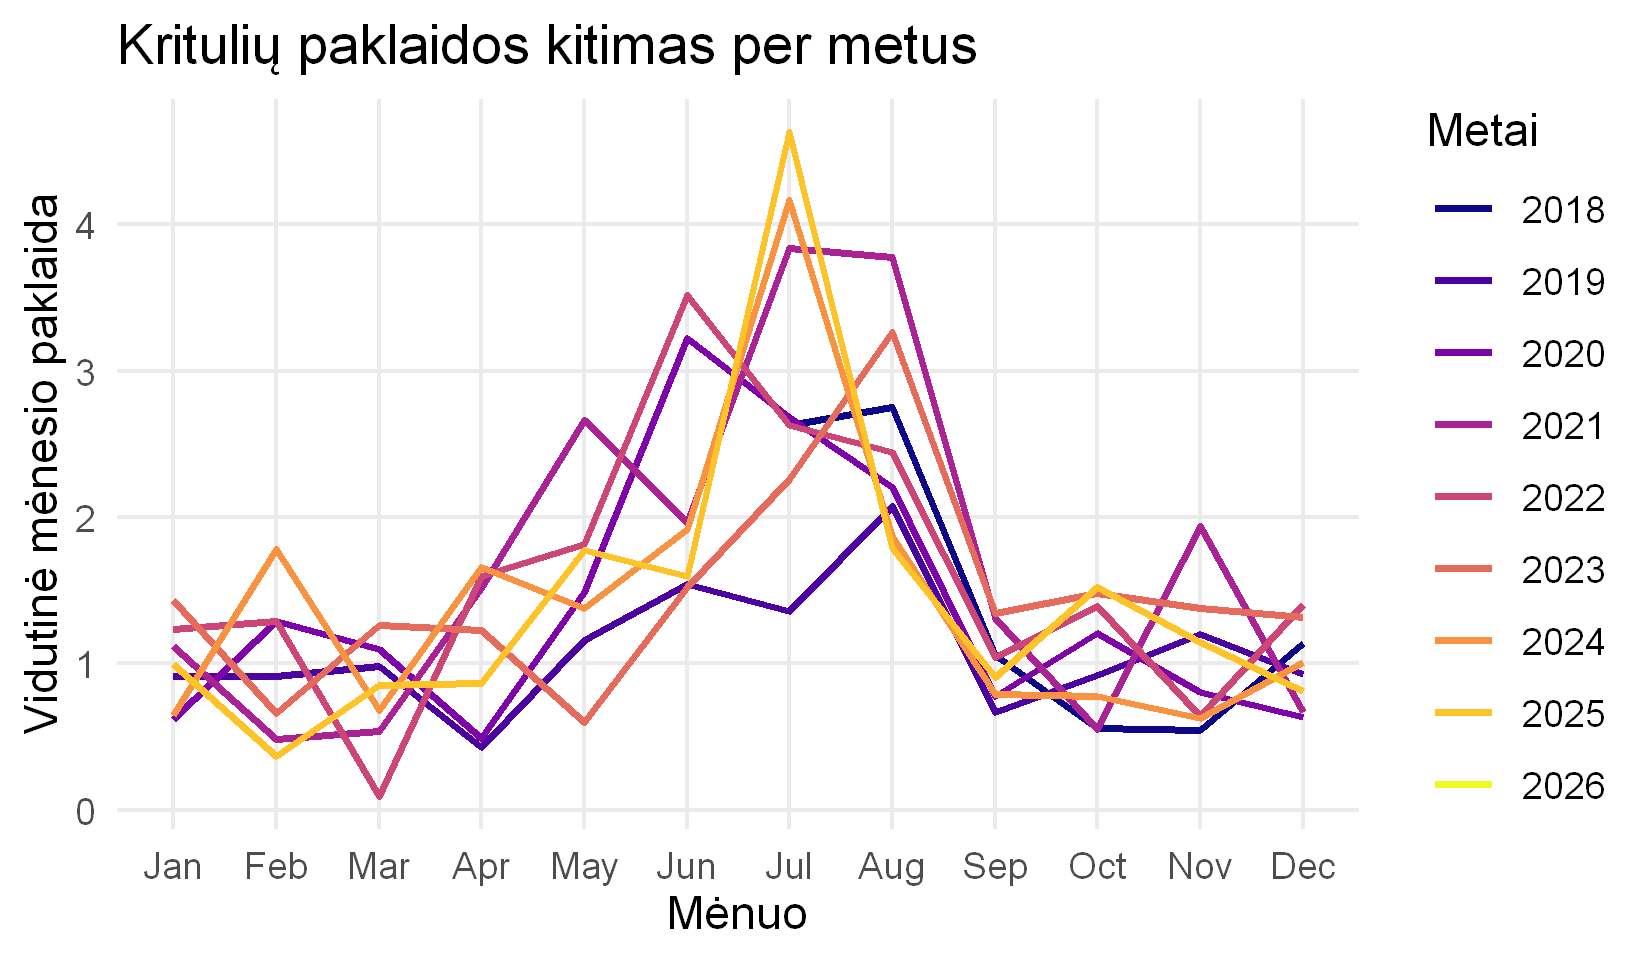

In [38]:
spaghetti_data <- data_clean %>%
  mutate(
    month = month(time),
    year = as.factor(year(time))
  ) %>%
  group_by(year, month) %>%
  summarise(tp_error_mean = mean(tp_error, na.rm = TRUE), .groups = "drop")

  
ggplot(spaghetti_data, aes(x = month, y = tp_error_mean, group = year, color = year)) +
  geom_line(size = 0.8) +
  scale_x_continuous(breaks = 1:12, labels = month.abb) +
  scale_color_viridis_d(option = "plasma") + 
  theme_minimal() +
  labs(
    title = "Kritulių paklaidos kitimas per metus",
    x = "Mėnuo",
    y = "Vidutinė mėnesio paklaida",
    color = "Metai"
  ) +
  theme(
    panel.grid.minor = element_blank(),
    legend.position = "right"
  )

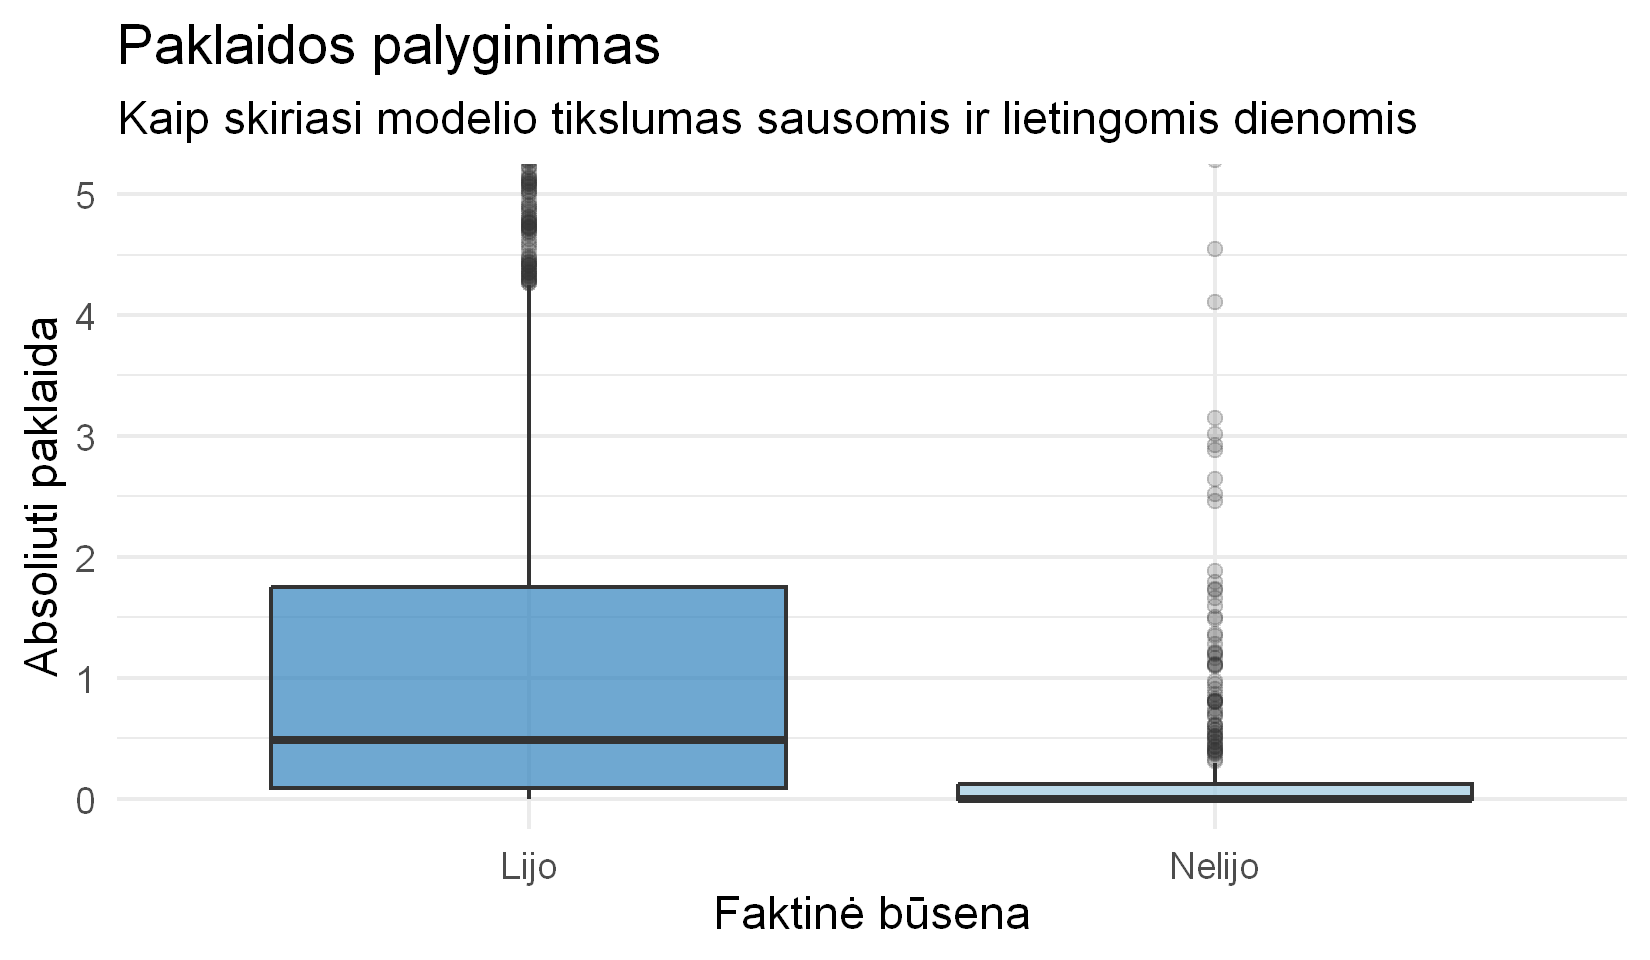

In [39]:
rain_detection_analysis <- data_clean %>%
  mutate(
    rain_status = if_else(tp > 0, "Lijo", "Nelijo")
  )

ggplot(rain_detection_analysis, aes(x = rain_status, y = tp_error, fill = rain_status)) +
  geom_boxplot(outlier.alpha = 0.2, alpha = 0.7) +
  theme_minimal() +
  coord_cartesian(ylim = c(0, 5)) +
  scale_fill_manual(values = c("Lijo" = "#3182bd", "Nelijo" = "#9ecae1")) +
  labs(
    title = "Paklaidos palyginimas",
    subtitle = "Kaip skiriasi modelio tikslumas sausomis ir lietingomis dienomis",
    x = "Faktinė būsena",
    y = "Absoliuti paklaida",
    fill = "Būsena"
  ) +
  theme(legend.position = "none")

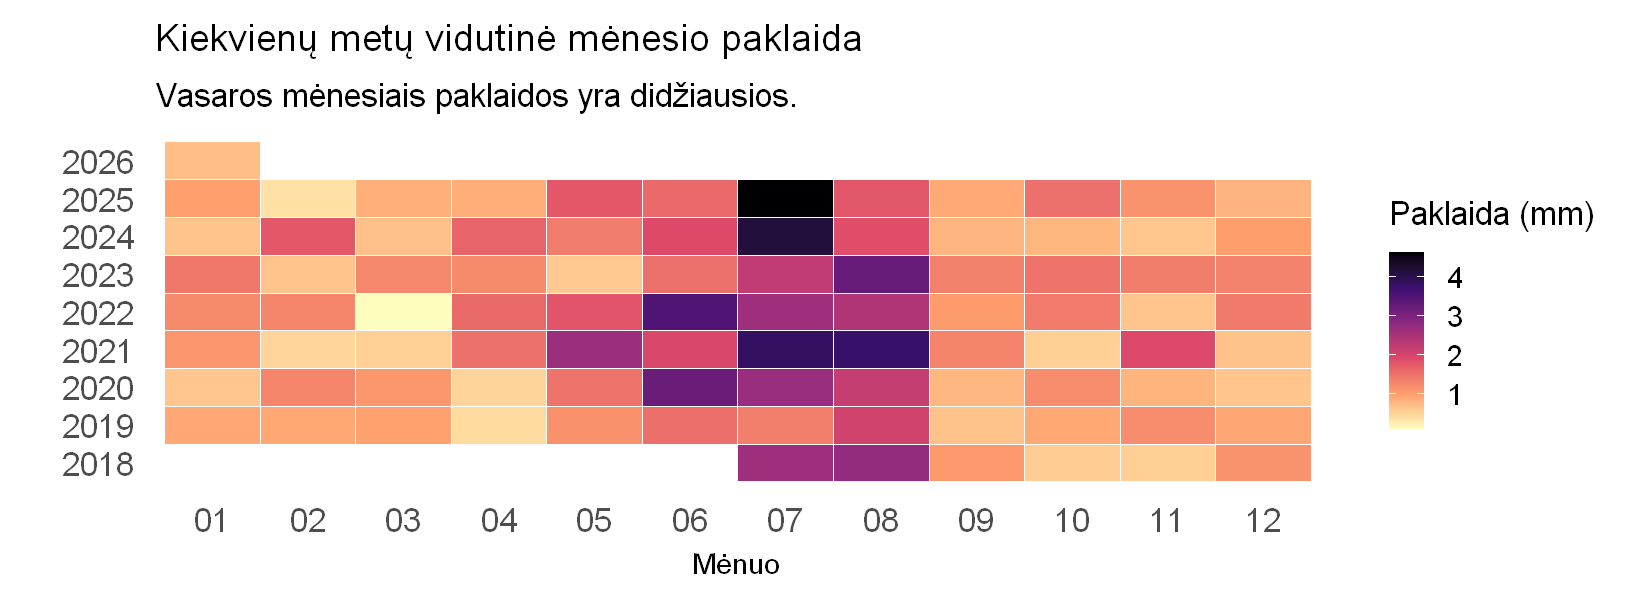

In [111]:
options(repr.plot.width = 5.5, repr.plot.height = 2, repr.plot.res = 300)

heatmap_data <- data_clean %>%
  mutate(
    month = sprintf("%02d", month(time)),
    year = year(time)
  ) %>%
  group_by(year, month) %>%
  summarise(mean_error = mean(tp_error, na.rm = TRUE), .groups = "drop")

ggplot(heatmap_data, aes(x = month, y = factor(year), fill = mean_error)) +
  geom_tile(color = "white") + 
  scale_fill_viridis_c(option = "magma", direction = -1) + 
  theme_minimal() +
  labs(
    title = "Kiekvienų metų vidutinė mėnesio paklaida",
    x = "Mėnuo",
    y = "",
    fill = "Paklaida (mm)",
    subtitle = "Vasaros mėnesiais paklaidos yra didžiausios."
  ) +
  theme(
    panel.grid = element_blank(),
    axis.text.x = element_text(angle = 0, size = 8),
    plot.subtitle = element_text(size = 8),
    axis.text.y = element_text(size = 8),
    axis.title.x = element_text(size = 7),
    axis.title.y = element_text(size = 7),
    plot.title = element_text(size = 9),
    legend.text = element_text(size = 7),
    legend.key.size = unit(0.3, "cm"),
    legend.title = element_text(size = 8)
  )

ggsave(filename = "heatmap_error.png", width = 5.5,
  height = 2, units = "in",
  dpi = 300)

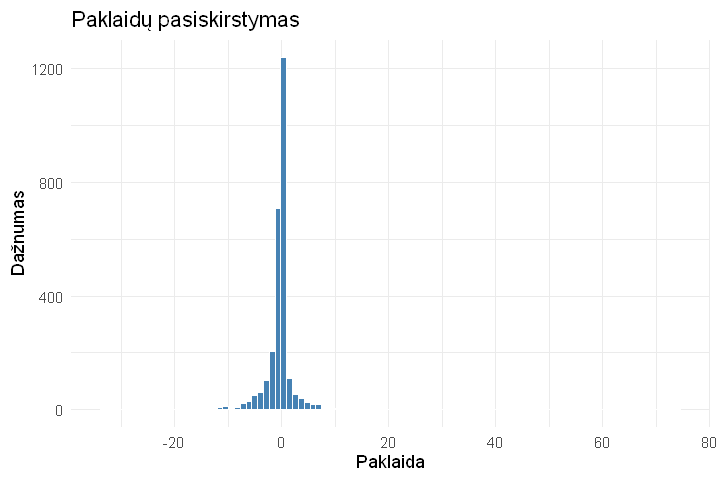

In [50]:
options(repr.plot.width = 6, repr.plot.height = 4)
ggplot(data_clean, aes(x = missforest_precipitation - tp_lag)) +
  geom_histogram(bins = 100, fill = "steelblue", color = "white") +
  # geom_vline(xintercept = 0, color = "red", linetype = "dashed") +
  theme_minimal() +
  labs(
    title = "Paklaidų pasiskirstymas",
    x = "Paklaida", y = "Dažnumas"
  )

In [ ]:
library(tidyverse)
library(GGally)
library(viridis)

data_monthly <- data %>%
  dplyr::select(-c('BrO_Error', 'NO2_Error', 'O3_Error')) %>%
  na.omit() %>%
  mutate(Month = format(as.Date(time), "%m")) %>% 
  group_by(Month) %>%
  summarise(across(where(is.numeric), mean, na.rm = TRUE)) %>%
  ungroup()


data_scaled <- data_monthly %>%
  mutate(across(-Month, ~ (.-min(.))/(max(.)-min(.))))

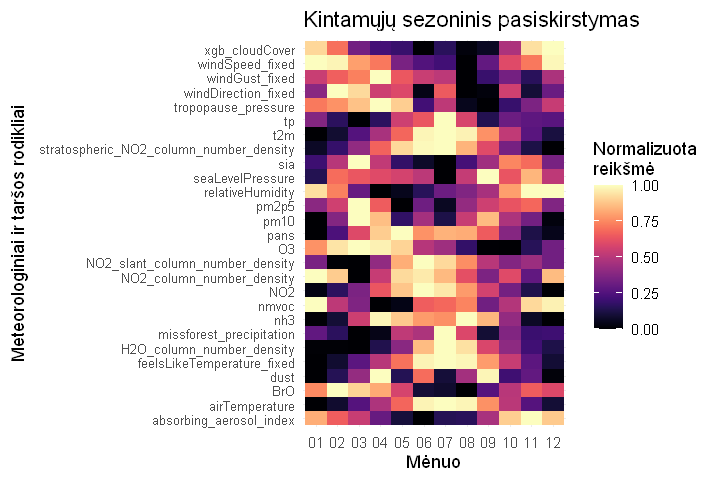

In [72]:
data_long <- data_scaled %>%
  pivot_longer(-Month, names_to = "Kintamasis", values_to = "Reiksme")

ggplot(data_long, aes(x = Month, y = Kintamasis, fill = Reiksme)) +
  geom_tile() +
  scale_fill_viridis(option = "magma", name = "Normalizuota\nreikšmė") +
  theme_minimal() +
  labs(title = "Kintamųjų sezoninis pasiskirstymas",
       x = "Mėnuo", y = "Meteorologiniai ir taršos rodikliai") +
  theme(axis.text.y = element_text(size = 8))

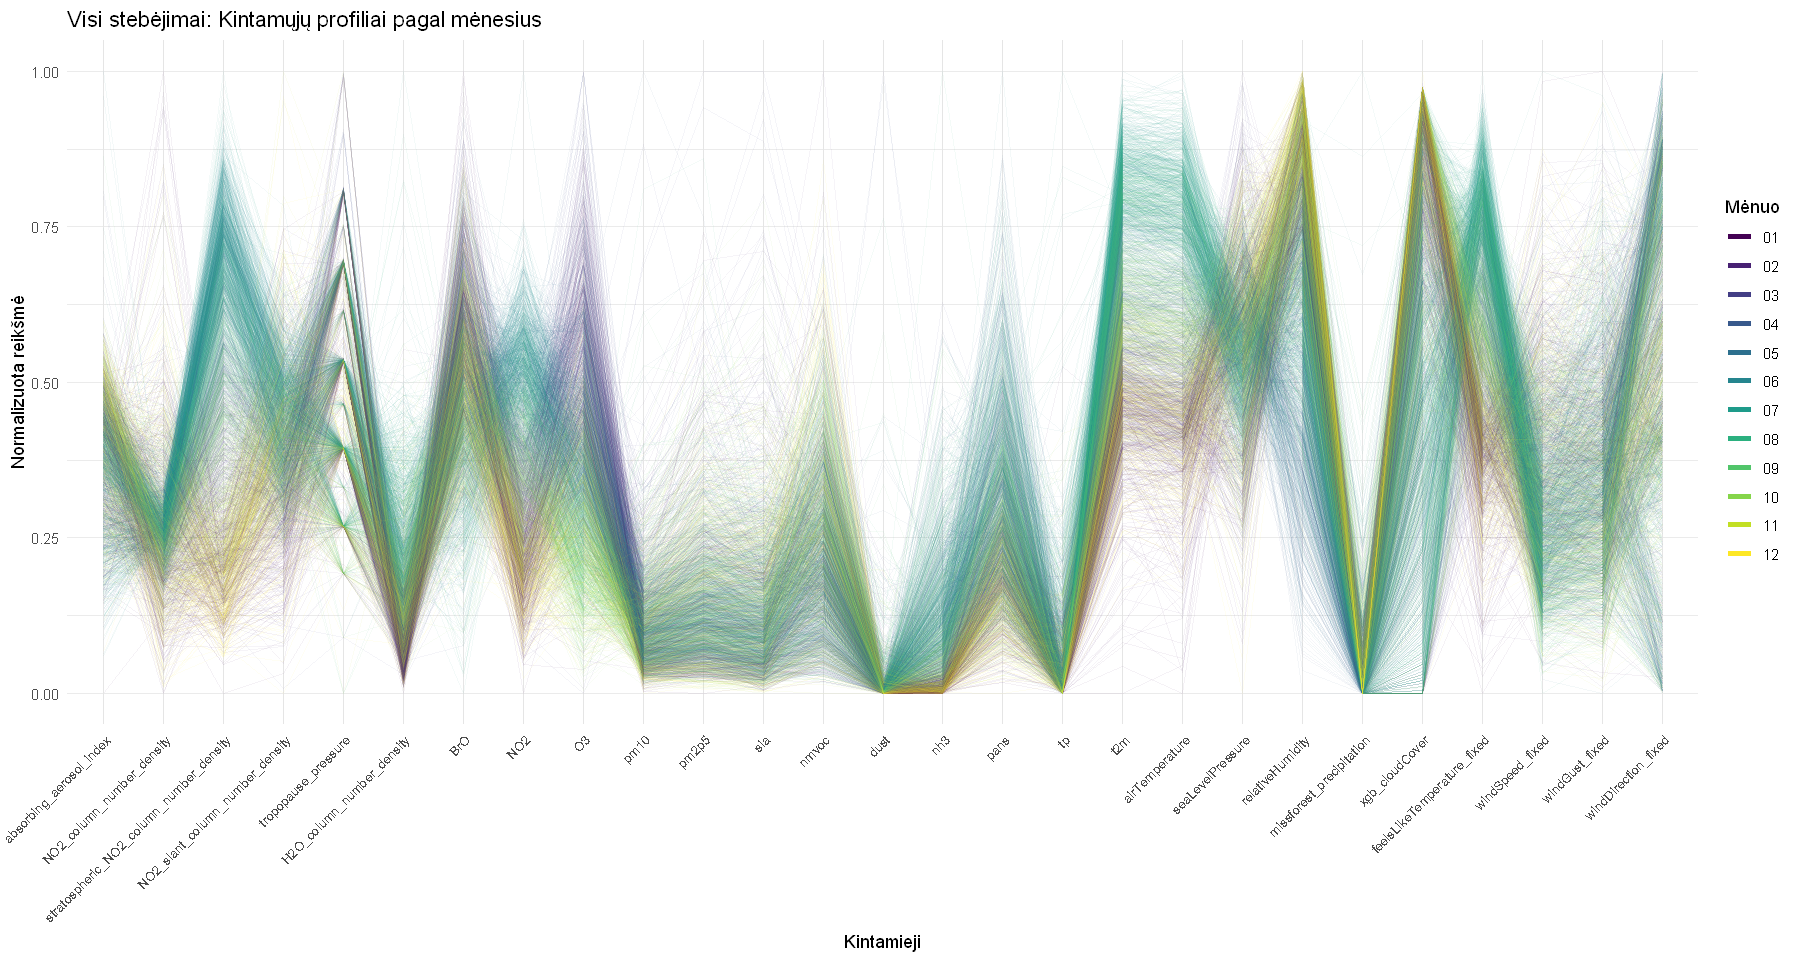

In [ ]:
library(GGally)

options(repr.plot.width = 15, repr.plot.height = 8)

data_full_plot <- data %>%
  dplyr::select(-c('BrO_Error', 'NO2_Error', 'O3_Error')) %>%
  mutate(
    Month = format(as.Date(time), "%m"),
    Year = format(as.Date(time), "%Y")
  ) %>% 
  filter(!Year %in% c("2018", "2026")) %>%
  dplyr::select(-time, -Year) %>%
  
  mutate(across(where(is.numeric), ~ (.-min(., na.rm=T))/(max(., na.rm=T)-min(., na.rm=T)))) %>%
  
  dplyr::select(Month, everything())

ggparcoord(data_full_plot,
           columns = 2:ncol(data_full_plot),
           groupColumn = "Month",
           scale = "globalminmax",
           alphaLines = 0.05,
           title = "Visi stebėjimai: Kintamųjų profiliai pagal mėnesius") +
  theme_minimal() +
  scale_color_viridis_d(option = "viridis") +
  theme(axis.text.x = element_text(angle = 45, hjust = 1, size = 8),
        legend.position = "right",
        panel.grid.major.x = element_line(color = "gray90")) +
  labs(x = "Kintamieji", y = "Normalizuota reikšmė", color = "Mėnuo") +
  guides(colour = guide_legend(override.aes = list(alpha = 1, linewidth = 1.5)))